# BundleFit DEMO
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opensrcai/bundlefit/blob/main/example_py/notebooks/bundle_adjustment.ipynb)

In [1]:
! apt-get -y update && apt-get -y install libeigen3-dev libceres-dev libspdlog-dev libopencv-dev nlohmann-json3-dev

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [2,830 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,517 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd

In [2]:
! pip install matplotlib open3d numpy scipy nanobind

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.7/399.7 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.7 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  A

In [3]:
! rm -rf bundlefit && git clone https://github.com/opensrcai/bundlefit.git && \
  cd bundlefit && pip install .

Cloning into 'bundlefit'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 69 (delta 7), reused 69 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 58.91 KiB | 3.10 MiB/s, done.
Resolving deltas: 100% (7/7), done.
Processing /content/bundlefit
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for bundlefit: filename=bundlefit-0.0.1-cp310-cp310-linux_x86_64.whl size=144897 sha256=8c0656d8556ef4f46ed504764b5732670841cdd20dca8f94fb656381bb9eec15
  Stored in directory: /tmp/pip-ephem-wheel-cache-x4mxpcma/wheels/ee/82/e2/9128d71eaa548d8c871f90132ac96c693a01c16a76743e77da
Successfully built bundlefit


In [4]:
import bundlefit

In [5]:
import os
import open3d as o3d
import shutil
import urllib.request
import numpy as np
from scipy.spatial.transform import Rotation

## Download data

In [6]:
# Dataset URL
# https://www.epfl.ch/labs/mmspg/downloads/geometry-point-cloud-dataset/
# Reference
# E. Alexiou and T. Ebrahimi, “On the performance of metrics to predict quality in point cloud representations,” Proc. SPIE 10396, Applications of Digital Image Processing XL, 103961H (19 September 2017). doi: 10.1117/12.2275142
# E. Alexiou, E. Upenik and T. Ebrahimi, “Towards subjective quality assessment of point cloud imaging in augmented reality,” 2017 IEEE 19th International Workshop on Multimedia Signal Processing (MMSP), Luton, 2017, pp. 1-6. doi: 10.1109/MMSP.2017.8122237
url = "https://www.epfl.ch/labs/mmspg/wp-content/uploads/2020/06/G-PCD.zip"
zip_filepath = url.split("/")[-1]

In [7]:
download = True

In [8]:
if download:
    with urllib.request.urlopen(url) as content:
        zip_file = content.read()
        with open(zip_filepath, mode='wb') as fs:
            fs.write(zip_file)

In [9]:
out_dir = "".join(zip_filepath.split(".")[:-1])

In [10]:
if download:
    shutil.unpack_archive(zip_filepath, out_dir)

In [11]:
point_cloud = o3d.io.read_point_cloud(os.path.join(out_dir, "G-PCD", "stimuli", "D01", "bunny.ply"))

In [12]:
np_points = np.asarray(point_cloud.points)
num_points = len(np_points)

In [13]:
bbox_min = np_points.min(axis=0)
bbox_max = np_points.max(axis=0)

bbox_min, bbox_max

(array([0., 0., 0.]), array([1.      , 0.99123 , 0.775042]))

## Set up camera poses

In [14]:
num_camera = 8
target = (bbox_min + bbox_max) / 2
target = target[None, :].repeat(num_camera, axis=0)
target

array([[0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521],
       [0.5     , 0.495615, 0.387521]])

In [15]:
ups = np.array([[0, -1, 0] for _ in range(num_camera)])
ups

array([[ 0, -1,  0],
       [ 0, -1,  0],
       [ 0, -1,  0],
       [ 0, -1,  0],
       [ 0, -1,  0],
       [ 0, -1,  0],
       [ 0, -1,  0],
       [ 0, -1,  0]])

In [16]:
circle_y_coord = (bbox_min[1] + bbox_max[1]) / 2
circle_center_x = (bbox_min[0] + bbox_max[0]) / 2
circle_center_z = (bbox_min[2] + bbox_max[2]) / 2

circle_radius = np.linalg.norm(bbox_max[[0, 2]] - bbox_min[[0, 2]]) * 1.25

eyes = np.array([[np.cos(2 * np.pi * (i / num_camera)), circle_y_coord, np.sin(2 * np.pi * (i / num_camera))] for i in range(num_camera)])
eyes[:, 0] = eyes[:, 0] * circle_radius + circle_center_x
eyes[:, 2] = eyes[:, 2] * circle_radius + circle_center_z
eyes

array([[ 2.08147978,  0.495615  ,  0.387521  ],
       [ 1.61827507,  0.495615  ,  1.50579607],
       [ 0.5       ,  0.495615  ,  1.96900078],
       [-0.61827507,  0.495615  ,  1.50579607],
       [-1.08147978,  0.495615  ,  0.387521  ],
       [-0.61827507,  0.495615  , -0.73075407],
       [ 0.5       ,  0.495615  , -1.19395878],
       [ 1.61827507,  0.495615  , -0.73075407]])

In [17]:
def normalize(v: np.ndarray):
  norm = np.linalg.norm(v, axis=-1)

  return v / np.expand_dims(norm, axis=-1)

def look_at(eyes:np.ndarray, targets: np.ndarray, ups: np.ndarray):
  assert eyes.shape[0] == targets.shape[0]
  assert targets.shape[0] == ups.shape[0]
  num_camera = eyes.shape[0]

  T = np.array([np.eye(4) for _ in range(num_camera)])
  T[:, 0:3, 3] =  -eyes

  R = np.array([np.eye(4) for _ in range(num_camera)])
  zs = normalize(targets - eyes)
  xs = normalize(np.cross(ups, zs, axis=-1))
  ys = normalize(np.cross(zs, xs, axis=-1))

  R[:, 0, 0:3] = xs
  R[:, 1, 0:3] = ys
  R[:, 2, 0:3] = zs

  return R @ T

transforms = look_at(eyes, target, ups)
transforms

array([[[ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00,
          3.87521000e-01],
        [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00,
          4.95615000e-01],
        [-1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          2.08147978e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]],

       [[ 7.07106781e-01,  0.00000000e+00, -7.07106781e-01,
         -7.95346636e-02],
        [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00,
          4.95615000e-01],
        [-7.07106781e-01,  0.00000000e+00, -7.07106781e-01,
          2.20905189e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]],

       [[ 1.00000000e+00,  0.00000000e+00, -7.02015316e-17,
         -5.00000000e-01],
        [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00,
          4.95615000e-01],
        [-7.02015316e-17,  0.00000000e+00, -1.00000000e+00,
          1.96900078e+00],
        [ 0.00000000e+00,  0.00000000e+

In [18]:
rotations = transforms[:, 0:3, 0:3]
translations = transforms[:, 0:3, 3]

rotations, translations

(array([[[ 0.00000000e+00,  0.00000000e+00, -1.00000000e+00],
         [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
         [-1.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
 
        [[ 7.07106781e-01,  0.00000000e+00, -7.07106781e-01],
         [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
         [-7.07106781e-01,  0.00000000e+00, -7.07106781e-01]],
 
        [[ 1.00000000e+00,  0.00000000e+00, -7.02015316e-17],
         [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
         [-7.02015316e-17,  0.00000000e+00, -1.00000000e+00]],
 
        [[ 7.07106781e-01,  0.00000000e+00,  7.07106781e-01],
         [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
         [ 7.07106781e-01,  0.00000000e+00, -7.07106781e-01]],
 
        [[ 1.05302297e-16,  0.00000000e+00,  1.00000000e+00],
         [ 0.00000000e+00, -1.00000000e+00,  0.00000000e+00],
         [ 1.00000000e+00,  0.00000000e+00, -1.05302297e-16]],
 
        [[-7.07106781e-01,  0.00000000e+00,  7.07106781

In [19]:
rows = 1080
cols = 1080
fov = 60 / 180 * np.pi

# FIXME: fx, fy cx, cy
fx = fy = cols / (2 * np.tan(fov / 2))
cx = cols / 2
cy = rows / 2

fx, fy, cx, cy

(935.3074360871938, 935.3074360871938, 540.0, 540.0)

## Project points

In [20]:
def world_to_camera(points: np.ndarray, rotations: np.ndarray, translations: np.ndarray):
    "`rotations` and `translations` are world to local transfomation."
    assert points.ndim == 3
    assert points.shape[2] == 3

    points_c = (rotations[:, None, :, :] @ points[:, :, :, None]).squeeze(
        -1
    ) + translations[:, None, :]

    return points_c

In [21]:
np_points_c = world_to_camera(np_points[np.arange(num_points)[None, :].repeat(num_camera, axis=0)], rotations, translations)
np_points_c.shape

(8, 35947, 3)

In [22]:
X = np_points_c[:, :, 0]
Y = np_points_c[:, :, 1]
Z = np_points_c[:, :, 2]

u = (fx * X + cx * Z) / Z
v = (fy * Y + cy * Z) / Z
u

array([[518.95855407, 528.2584755 , 418.19051974, ..., 670.76415625,
        547.21588002, 563.01421608],
       [470.46858312, 461.2538394 , 306.86027427, ..., 515.35603366,
        508.74828089, 498.99673244],
       [458.27821559, 432.37125861, 309.35789575, ..., 365.97782242,
        486.55247893, 454.17262876],
       ...,
       [615.78145189, 630.66374584, 790.40938189, ..., 583.27821965,
        574.30031111, 588.68728799],
       [617.82649673, 644.66134047, 707.94504373, ..., 785.43473498,
        594.32690073, 630.57702125],
       [577.3336196 , 600.35750892, 566.54965986, ..., 788.26290004,
        582.02821438, 616.48965354]])

In [23]:
in_frame = np.logical_and(np.logical_and(0 <= u, u < cols), np.logical_and(0 <= v, v <= rows))

In [24]:
in_frame.sum(axis=1) / num_points * 100

array([100., 100., 100., 100., 100., 100., 100., 100.])

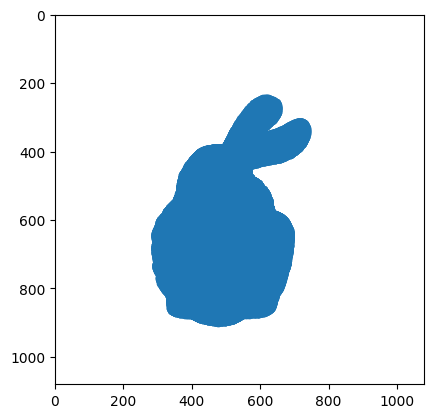

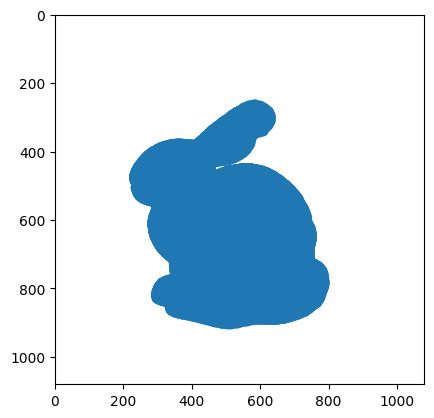

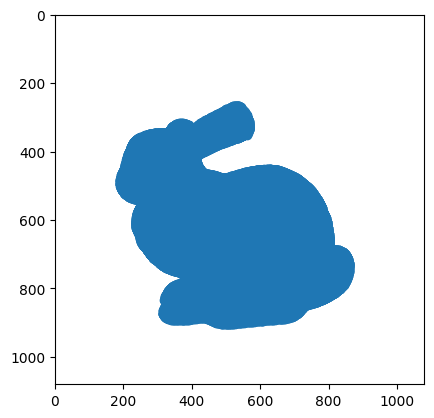

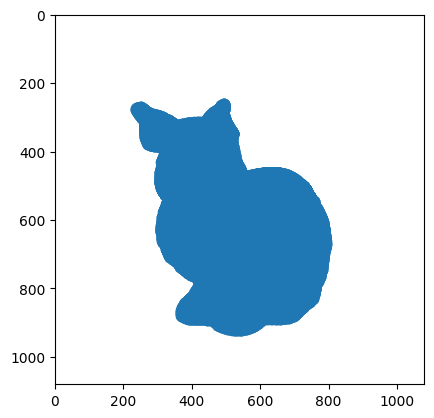

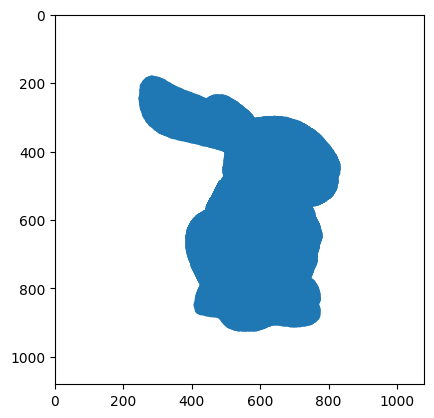

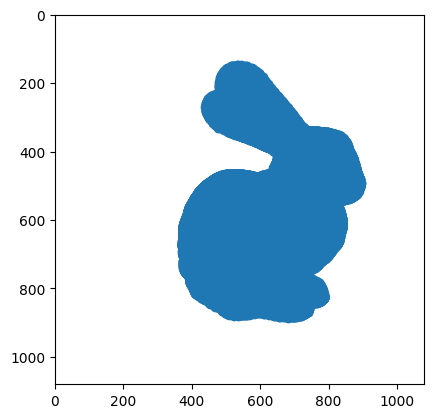

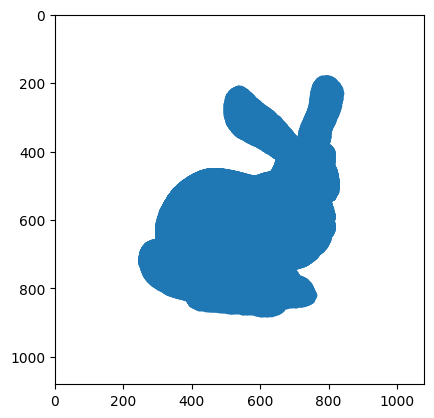

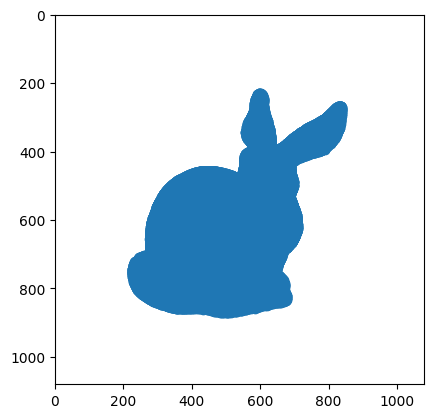

In [25]:
import matplotlib.pyplot as plt

for i in range(num_camera):
    fig = plt.subplot()
    fig.scatter(u[i,:], v[i,:])
    plt.xlim(0, cols)
    plt.ylim(rows, 0)
    fig.set_aspect('equal')
    plt.show()

## Add noise to points

In [26]:
sigma = np.sort(bbox_max - bbox_min)[1] * 0.2

sigma

0.19824600000000003

In [27]:
generator = np.random.default_rng()
np_points_with_noise = np_points + generator.normal(size=np_points.shape,loc=0,scale=sigma)
np_points_with_noise

array([[ 0.10207289,  0.59774704,  0.60319475],
       [ 0.25168869,  0.54592728,  0.16355674],
       [ 0.3246352 ,  0.6375592 ,  0.59420637],
       ...,
       [-0.00181314,  0.60568791,  0.1124327 ],
       [ 0.40671831,  0.64187904,  0.30160899],
       [ 0.74466012,  0.50821369,  0.2972161 ]])

In [28]:
np.abs(np_points - np_points_with_noise).mean()

0.15853472207059333

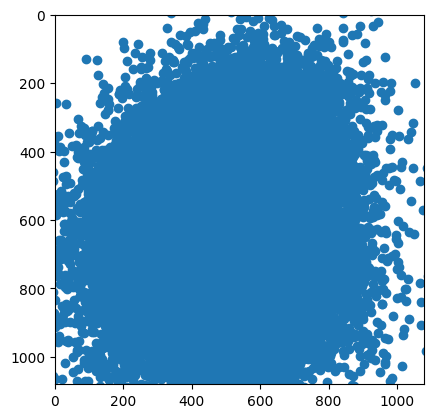

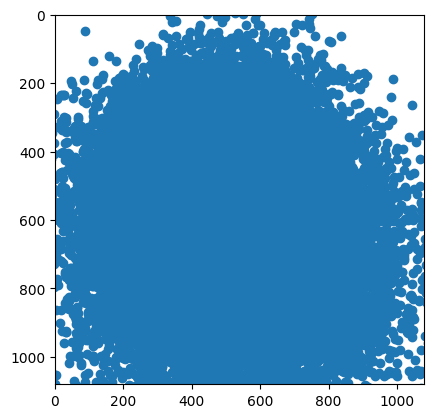

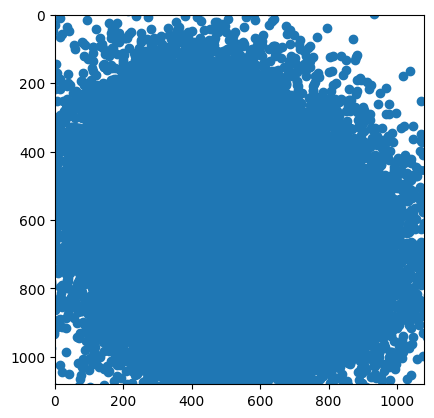

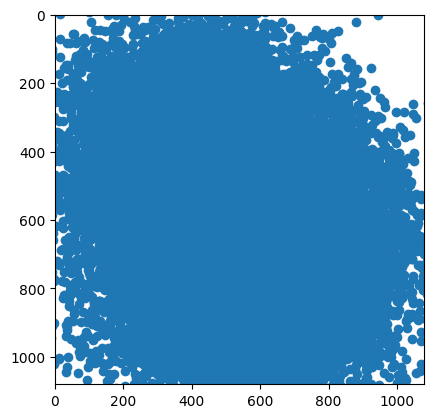

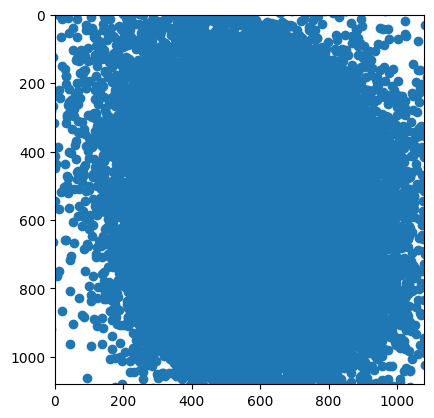

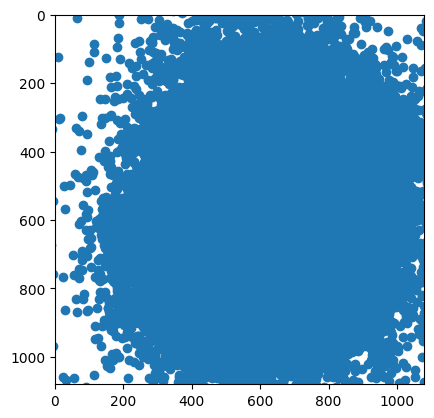

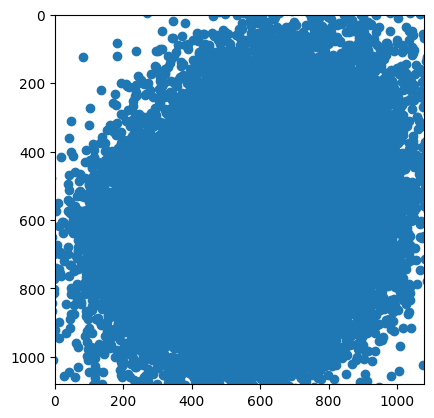

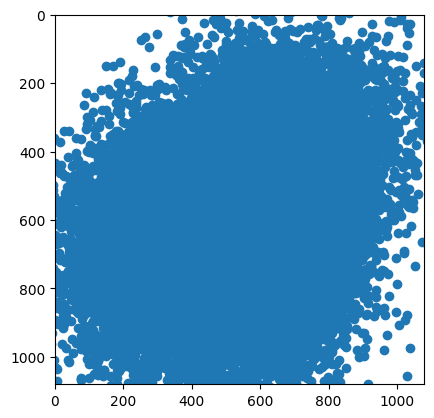

In [29]:
np_points_with_noise_c = world_to_camera(np_points_with_noise[np.arange(num_points)[None, :].repeat(num_camera, axis=0)], rotations, translations)

X_with_noise = np_points_with_noise_c[:, :, 0]
Y_with_noise = np_points_with_noise_c[:, :, 1]
Z_with_noise = np_points_with_noise_c[:, :, 2]

u_with_noise = (fx * X_with_noise + cx * Z_with_noise) / Z_with_noise
v_with_noise = (fy * Y_with_noise + cy * Z_with_noise) / Z_with_noise
for i in range(num_camera):
    fig = plt.subplot()
    fig.scatter(u_with_noise[i,:], v_with_noise[i,:])
    plt.xlim(0, cols)
    plt.ylim(rows, 0)
    fig.set_aspect('equal')
    plt.show()

***TODO: Add noise to camera poses.***

##  Optimize

In [30]:
bundle_adjuster = bundlefit.BundleAdjuster(4, True, True)

In [31]:
bundle_adjuster.add_perspective_camera(0, fx, fy, cx, cy, bundlefit.FLAG_FIX_INTRINSIC_PARAMS)

In [32]:
shot_ids = np.arange(num_camera)
rotation_vecs = Rotation.from_matrix(rotations).as_rotvec()
shot_params = np.concatenate([rotation_vecs, translations], axis=1)
flags = np.full((num_camera, ), bundlefit.FLAG_FIX_PARAMS, dtype=np.int32)

bundle_adjuster.add_SE3_shots(shot_ids, shot_params, flags)
shot_params.shape

(8, 6)

In [33]:
lm_ids = np.arange(num_points)
flags = np.full((num_points, ), bundlefit.FLAG_OPTIMIZE_PARAMS , dtype=np.int32)
local_coord_shot_id = [None for _ in range(num_points)]

bundle_adjuster.add_landmarks(lm_ids, np_points_with_noise, flags, local_coord_shot_id)

In [34]:
for i in range(num_camera):
    num_correspondences = int(np.sum(in_frame[i]))
    camera_ids = np.zeros(num_correspondences, dtype=np.uint32)
    shot_ids = np.full(num_correspondences, i, dtype=np.uint32)
    landmark_ids = np.arange(num_points, dtype=np.uint32)[in_frame[i]]
    uv = np.stack([u[i][in_frame[i]], v[i][in_frame[i]]], axis=1)
    info_vals = np.full((num_correspondences,), 1.0, dtype=np.float64)
    loss_types = np.full((num_correspondences,), int(bundlefit.LossType.TRIVIAL))
    loss_scale = np.full((num_correspondences,), 1.0, dtype=np.float64)

    bundle_adjuster.add_reprojection_errors(camera_ids, shot_ids, landmark_ids, uv, info_vals, loss_types, loss_scale)

In [35]:
bundle_adjuster.construct_problem()

In [36]:
bundle_adjuster.fit(20, True, True)

## Draw optimization results

In [37]:
np_points_optimized = bundle_adjuster.get_landmark_positions(lm_ids)

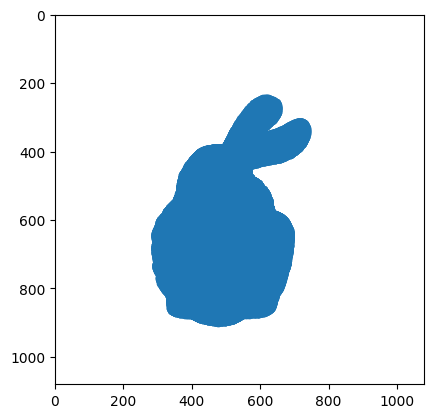

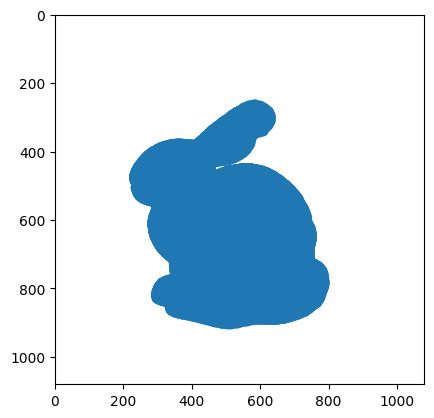

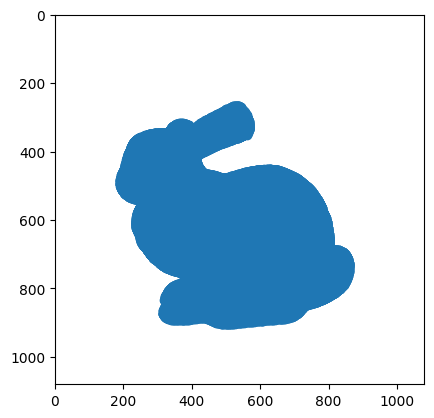

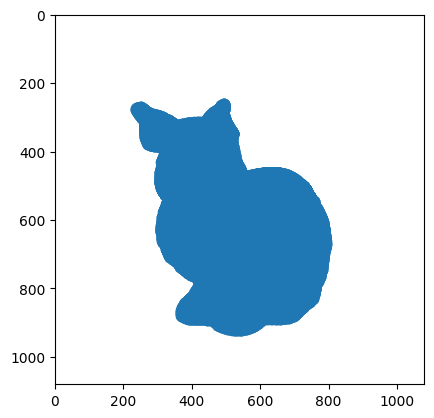

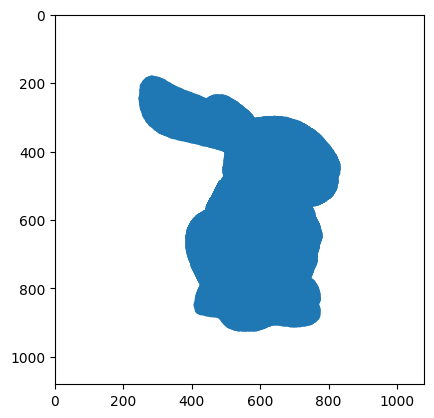

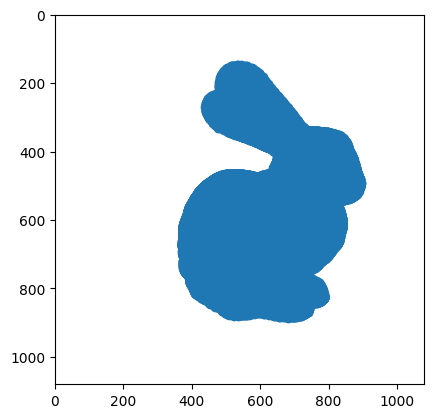

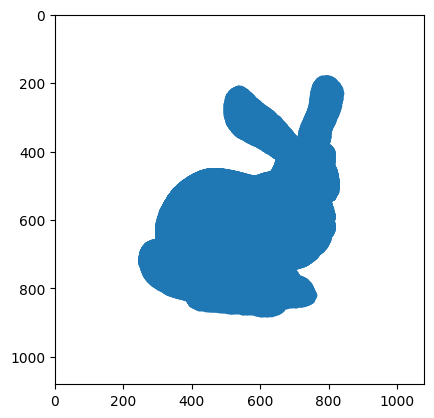

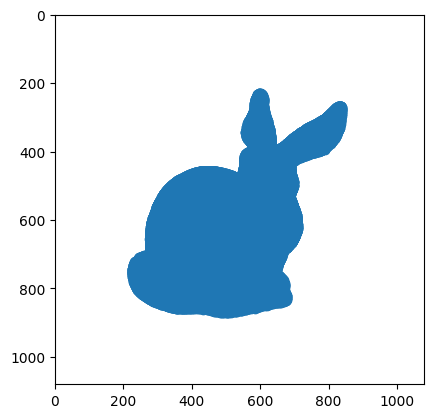

In [38]:
np_points_optimized_c = world_to_camera(np_points_optimized[np.arange(num_points)[None, :].repeat(num_camera, axis=0)], rotations, translations)

X_optimized = np_points_optimized_c[:, :, 0]
Y_optimized = np_points_optimized_c[:, :, 1]
Z_optimized = np_points_optimized_c[:, :, 2]

u_optimized = (fx * X_optimized + cx * Z_optimized) / Z_optimized
v_optimized = (fy * Y_optimized + cy * Z_optimized) / Z_optimized
for i in range(num_camera):
    fig = plt.subplot()
    fig.scatter(u_optimized[i,:], v_optimized[i,:])
    plt.xlim(0, cols)
    plt.ylim(rows, 0)
    fig.set_aspect('equal')
    plt.show()

In [39]:
np.abs(np_points - np_points_optimized).mean()

5.461364417760057e-16